# From scratch 

## import libraties

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## import dataset

In [4]:
from sklearn.datasets import load_diabetes
data = load_diabetes()


In [5]:
# this is the description of the Dataset
print(load_diabetes().DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
X = data.data
y = data.target

In [7]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [8]:
pd.DataFrame(y)

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


## train test split

In [9]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train,y_test = train_test_split(X,y,
                                                test_size=0.2,
                                                random_state=45
                                                )

In [10]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


## linear regression model fit

In [11]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train,y_train)

LinearRegression()

## r2 score linear regresion

In [12]:
# calucate predication on testing data
y_pred = linear_regression_model.predict(X_test)

In [13]:
from sklearn.metrics import r2_score ,root_mean_squared_error

print('R2 score', r2_score(y_test,y_pred))
print('RMSE',root_mean_squared_error(y_test,y_pred))


R2 score 0.5188113124539249
RMSE 48.72713760953253


Tho basically alpha parameter is lamba is disced in it          
the default value of alpha is 1

## Ridge Regression model fit

In [14]:
from sklearn.linear_model import Ridge

ridge_regression_model = Ridge(alpha=0.001) # basically it is lamba = 1

ridge_regression_model.fit(X_train,y_train)

Ridge(alpha=0.001)

## r2 score ridge regresion

In [15]:
y_pred = ridge_regression_model.predict(X_test)

In [16]:
from sklearn.metrics import r2_score ,root_mean_squared_error

print('R2 score', r2_score(y_test,y_pred))
print('RMSE',root_mean_squared_error(y_test,y_pred))

R2 score 0.5201448351821765
RMSE 48.65957177859252


tho slightly thoda better perform kar raha ridge compare to normal regression

## Ridge polynomial regression

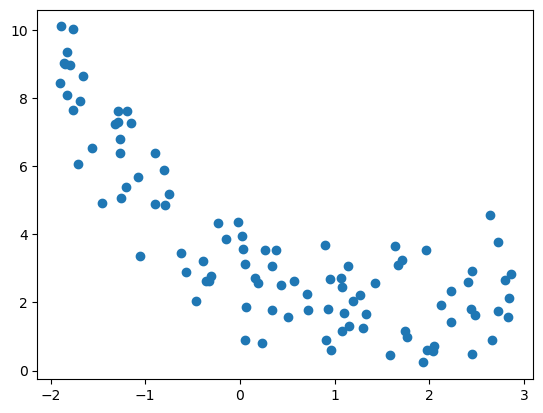

In [17]:
np.random.seed(555)
m = 100
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2*x1 + 3 + np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

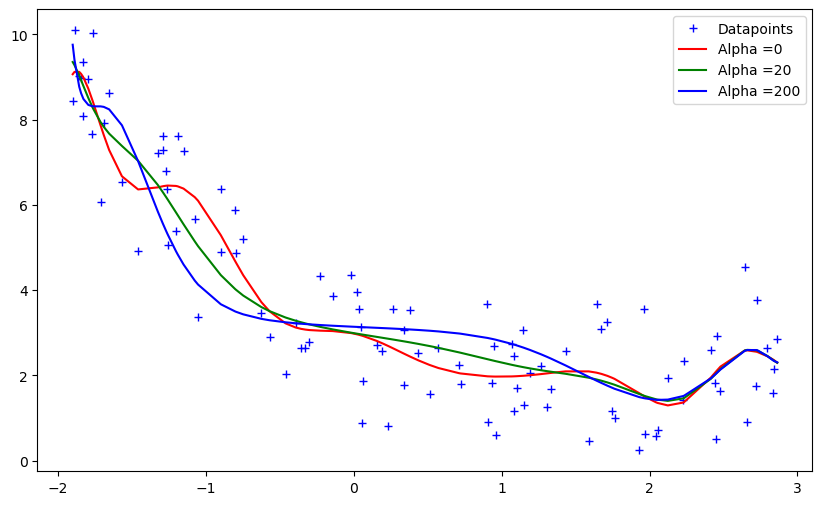

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)),
        ('ridge',Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label = 'Datapoints')

for alpha,c in zip(alphas,cs):
    preds = get_preds_ridge(x1,x2,alpha)
    # plot 
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label = 'Alpha ={}'.format(alpha))
    
plt.legend()
plt.show()

alpha = 0 ya 16 degree ka curve ha bhut jada overfit hona ka try kar raha ha bhut jada points sa gujarna ka koshish kar raha ha             
ya alpha = 20 optimum value of alpha  ek bitch ka balance aquire karna ki koshish kar raha ha 

- Red is Overfitting alpha value is low = 0
- blue is Underfitting alpha values is so high = 200
- green is Optimum model righ now jo bithch ka ek rasta ha 

# Ridge Regression from scratch m and b

### import libraries 

In [19]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### generate random regression data 

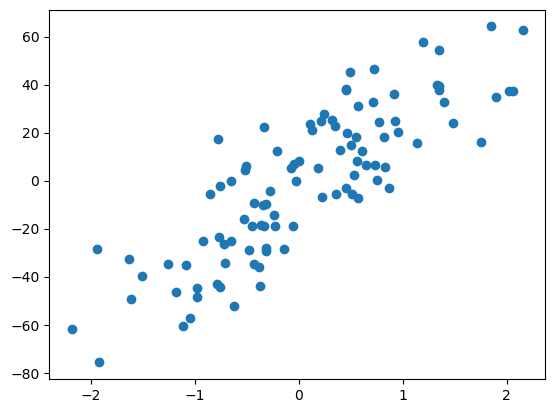

In [20]:
X,y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=20,
    random_state=13
)

plt.scatter(X,y)
plt.show()

### fit linear regression 

In [21]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(X,y)

print('slope :',linear_regression_model.coef_)
print('intercept :',linear_regression_model.intercept_)

slope : [27.82809103]
intercept : -2.29474455867698


### fit ridge regression 

In [22]:
from sklearn.linear_model import Ridge

# if i set alpha = 10
ridge_regression_model = Ridge(10)
ridge_regression_model.fit(X,y)


print('slope :',ridge_regression_model.coef_)
print('intercept :',ridge_regression_model.intercept_)

slope : [24.9546267]
intercept : -2.1269130035235735


In [23]:
# if i set alpha = 100


ridge_regression_model_1 = Ridge(100)
ridge_regression_model_1.fit(X,y)


print('slope :',ridge_regression_model_1.coef_)
print('intercept :',ridge_regression_model_1.intercept_)

slope : [12.93442104]
intercept : -1.4248441496033308


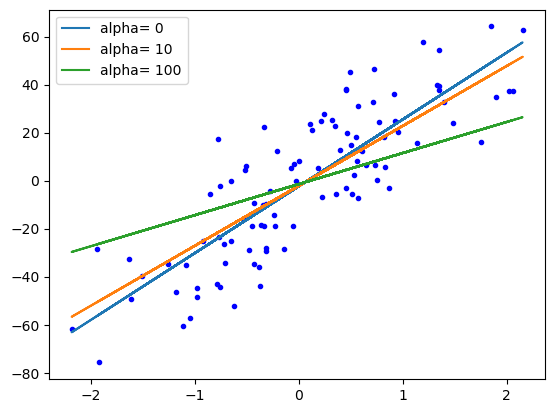

In [24]:
plt.plot(X,y,'b.')
plt.plot(X,linear_regression_model.predict(X),label = 'alpha= 0')
plt.plot(X,ridge_regression_model.predict(X),label = 'alpha= 10')
plt.plot(X,ridge_regression_model_1.predict(X),label = 'alpha= 100')

plt.legend()
plt.show()

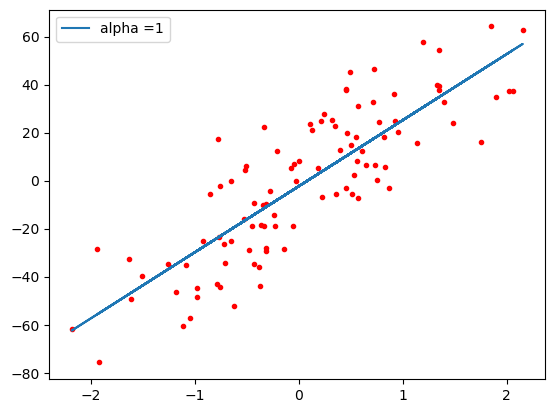

In [25]:
from sklearn.linear_model import Ridge

def Ridge_Regression(alpha_value = 1): # default is 1
    ridge_regression_model = Ridge(alpha=alpha_value)
    ridge_regression_model.fit(X,y)

    plt.plot(X,y,'r.')

    plt.plot(X,ridge_regression_model.predict(X),label = f'alpha ={alpha_value}')

    plt.legend()
    plt.show()
    
Ridge_Regression() 

### alpha value interactive graph

In [26]:
# now lets interact with alpha parameter and see its effect 
import ipywidgets as widgets
widgets.interact(Ridge_Regression ,alpha_value=(0,100,1))


interactive(children=(IntSlider(value=1, description='alpha_value'), Output()), _dom_classes=('widget-interact…

<function __main__.Ridge_Regression(alpha_value=1)>

# Our Ridge Reg class 2d

## intial bluepreint

In [ ]:
class  MeraRidge:
    
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        pass
    
    def predict(X_test):
        pass

now huma formula apply karna ha and loop chalna ha aor calculate karna ha 

## fit method 

In [32]:
class  MeraRidge:
    
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        num = 0
        den = 0
        
        for  i in range(X_train.shape[0]):
            num = num + (y_train[i]- y_train.mean()) * (X_train[i]- X_train.mean())
            den = den + (X_train[i]- X_train.mean()) * (X_train[i]- X_train.mean()) 
            
        self.m = num/den + self.alpha
        self.b = y_train.mean() - (self.m * X_train.mean())
        print('coeffiect :',self.m)
        print('intercept :',self.b)
    
    def predict(X_test):
        pass
    
reg_object = MeraRidge(alpha=10)
reg_object.fit(X,y)

coeffiect : [37.82809103]
intercept : [-2.87881847]


In [33]:
reg_object = MeraRidge(alpha=100)
reg_object.fit(X,y)

coeffiect : [127.82809103]
intercept : [-8.13548367]


# N dim Ridge Regularisation 

## import libraries

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

## load dataset

In [34]:
X,y = load_diabetes(return_X_y=True)

In [35]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [36]:
pd.DataFrame(y)

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


## train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train,y_test = train_test_split(X,y,
                                                test_size=0.2,
                                                random_state=45
                                                )

## fit Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

ridge_regression_model = Ridge(alpha=0.1,solver='cholesky')

# train the model
ridge_regression_model.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

## r2 score

In [39]:
y_pred = ridge_regression_model.predict(X_test)

In [40]:
print('r2 score :',r2_score(y_test,y_pred))

r2 score : 0.5208421054129915


In [42]:
print('coeffiect :',ridge_regression_model.coef_)
print('intercept :',ridge_regression_model.intercept_)

coeffiect : [  31.03389163 -204.8305909   464.8963454   304.96414918  -95.76037039
  -87.52969228 -183.81809293  147.49794012  425.85392451  110.21559915]
intercept : 152.07141290172817


# Our Ridge Reg class ndim

## inital blueprint

In [ ]:
class  MeraRidge:
    
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        pass
    
    def predict(X_test):
        pass

## fit method 

In [43]:
# insert 1 in the input matrix
np.insert(X_train,0,1,axis=1)

array([[ 1.        , -0.08906294, -0.04464164, ...,  0.03430886,
         0.02268774, -0.00936191],
       [ 1.        , -0.03457486, -0.04464164, ..., -0.00259226,
        -0.03074792, -0.07149352],
       [ 1.        ,  0.01628068,  0.05068012, ..., -0.03949338,
        -0.03074792,  0.03620126],
       ...,
       [ 1.        ,  0.01628068, -0.04464164, ..., -0.03395821,
        -0.05140387, -0.02593034],
       [ 1.        , -0.09632802, -0.04464164, ..., -0.03949338,
        -0.04688253, -0.07977773],
       [ 1.        ,  0.08166637,  0.05068012, ...,  0.09187461,
         0.05471997,  0.00720652]])

In [44]:
pd.DataFrame(np.insert(X_train,0,1,axis=1))

,0,1,2,3,4,5,6,7,8,9,10
0,1.0,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
1,1.0,-0.034575,-0.044642,-0.037463,-0.060756,0.020446,0.043466,-0.013948,-0.002592,-0.030748,-0.071494
2,1.0,0.016281,0.050680,-0.045007,0.063187,0.010815,-0.000374,0.063367,-0.039493,-0.030748,0.036201
3,1.0,0.038076,0.050680,-0.029918,-0.074527,-0.012577,-0.012587,0.004460,-0.002592,0.003709,-0.030072
4,1.0,-0.049105,-0.044642,0.160855,-0.046985,-0.029088,-0.019790,-0.047082,0.034309,0.028020,0.011349
...,...,...,...,...,...,...,...,...,...,...,...
348,1.0,-0.070900,-0.044642,-0.057941,-0.081413,-0.045599,-0.028871,-0.043401,-0.002592,0.001148,-0.005220
349,1.0,0.034443,0.050680,0.125287,0.028758,-0.053855,-0.012900,-0.102307,0.108111,0.000272,0.027917
350,1.0,0.016281,-0.044642,0.026128,0.058608,-0.060735,-0.044215,-0.013948,-0.033958,-0.051404,-0.025930
351,1.0,-0.096328,-0.044642,-0.069797,-0.067642,-0.019456,-0.010708,0.015505,-0.039493,-0.046883,-0.079778


In [ ]:
class  MeraRidge:
    
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha + I).dot(X_train.T).dot(y_train)
        
        self.intercept_ = result[0]
        self.coef_ = result[1:]
        
        print('intercept :',self.intercept_ )
        print('coefficent :',self.coef_ )
        
    def predict(X_test):
        pass
    
    
ridge_object = MeraRidge(alpha=10)
ridge_object.fit(X_train,y_train)

intercept : 151.17679660549416
coefficent : [ -32.26957297 -186.42214213  189.57190901  134.72050155  -23.48252546
  -91.44402771 -368.80957503    8.45182842  178.13052637   62.98485017]


## predict func 

In [48]:
class  MeraRidge:
    
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha + I).dot(X_train.T).dot(y_train)
        
        self.intercept_ = result[0]
        self.coef_ = result[1:]
        print('intercept :',self.intercept_ )
        print('coefficent :',self.coef_ )
        
    def predict(self,X_test):
        return np.dot(X_test, self.coef_) + self.intercept_
    
    
ridge_object = MeraRidge(alpha=10)
ridge_object.fit(X_train,y_train)

intercept : 151.17679660549416
coefficent : [ -32.26957297 -186.42214213  189.57190901  134.72050155  -23.48252546
  -91.44402771 -368.80957503    8.45182842  178.13052637   62.98485017]


In [51]:
ridge_object.predict(X_test)
print('r2 score ',r2_score(y_test,y_pred))

r2 score  0.5208421054129915


# Ridge Regression using Gradient Descant

## Using sklearn SGD Regressor

### import libraties

In [9]:
from sklearn.datasets   import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

###  load dataset

In [4]:
X,y = load_diabetes(return_X_y=True)

In [5]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [6]:
pd.DataFrame(y)

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


### train test split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.2,random_state=4)

In [ ]:
print(X_train.shape)
print(X_test.shape)

### fit model

In [10]:
# we use the stochastic gradient descant 
gradient_regression = SGDRegressor(
                            penalty='l2',
                            max_iter=500,
                            eta0=0.1,
                            learning_rate='constant',
                            alpha=0.001
                            )

gradient_regression.fit(X_train,y_train)

SGDRegressor(alpha=0.001, eta0=0.1, learning_rate='constant', max_iter=500)

In [11]:
print('intercept :',gradient_regression.intercept_)
print('coefficent :', gradient_regression.coef_)

intercept : [145.58280415]
coefficent : [ 148.83821509  -40.32557397  237.10603081  219.96160774   22.72921627
  -21.544481   -114.42417768  105.62768298  233.40533653  107.95547269]


### evaulte and check score

In [12]:
y_pred = gradient_regression.predict(X_test)
print('r2_score :', r2_score(y_test,y_pred))

r2_score : 0.41079921803773745


### gradient descant using Ridge

In [14]:
from sklearn.linear_model import Ridge

ridge_regression_model = Ridge(alpha=0.001,max_iter=500,solver='sparse_cg')

In [15]:
ridge_regression_model.fit(X_train,y_train)

print('intercept :', ridge_regression_model.intercept_)
print('coefficent :', ridge_regression_model.coef_)

y_pred = ridge_regression_model.predict(X_test)

print('r2_score :',r2_score(y_test,y_pred) )

intercept : 151.11410026356344
coefficent : [ 279.07548333 -378.56370549  297.47143109  563.37667851 -801.05697053
  308.78123105   94.28079704  345.94004821  539.02310435   29.96624166]
r2_score : 0.439618445810689


## Using our class

theta ko hum weight yani parameter matix ha

In [23]:
class MeraRidgeGD:
    
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [24]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [25]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4098864690486417
[ 141.93767292  -24.64086654  223.8034656   210.02770036   32.44034569
   -9.10272264 -113.25475279  111.44635869  227.92717142  110.21141649]
153.16472821800787


# 5 key Understanding 

## 1. How are coefficients affected?

In [33]:

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [27]:
data = load_diabetes()

In [34]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [35]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [36]:
df.shape

(442, 11)

In [37]:

X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [39]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))
    

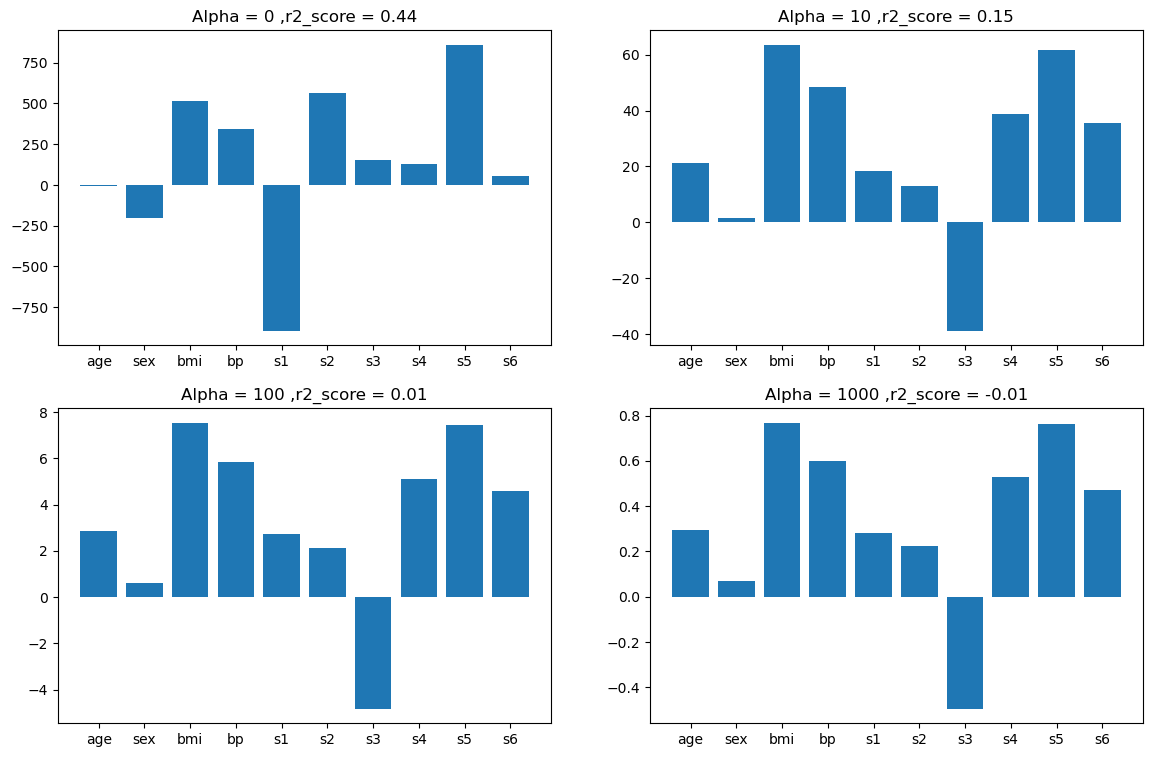

In [40]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

## 2. Higher Coefficients are affected more

In [43]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [44]:
input_array = np.array(coefs)

In [45]:
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


Observe :
if i increase the alpha values  gradually tho humna deka ki coefficent weights par kiya asar impace ho raha ha
- bmi = 516 sa 0.07 par aa gaya  bada wala ma jada asar hua
- age -9.16 sa 0.02 par aa gaya chota wala ma kam asar hua

same information ko graph ka throgh convey kar sakta hoa 

In [47]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [48]:
input_array = np.array(coefs).T

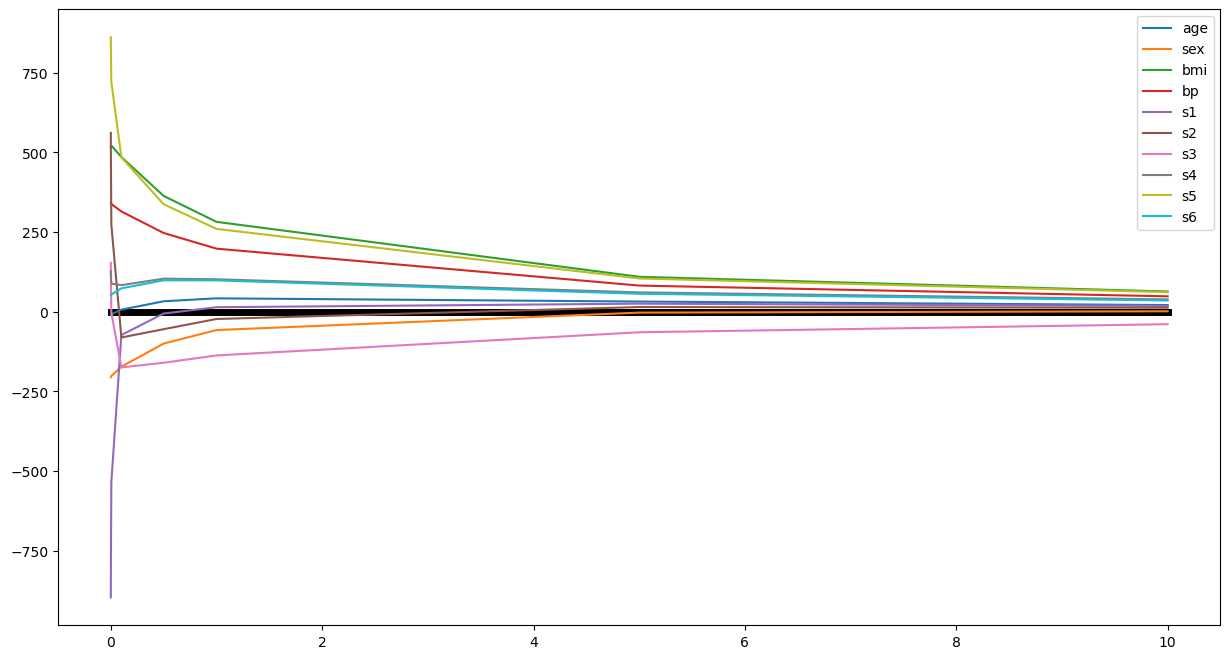

In [49]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()
plt.show()

x axis ma hyperpaameter value lamda ,alpha ki and y axis ma apka parameter ki values 

deko s5 ka inital value tha kitna bada  861 fir vo aa gaya 0.07 par  kitna tezi sa vo decrease hua 

## 3. Impact on Bias and Variance

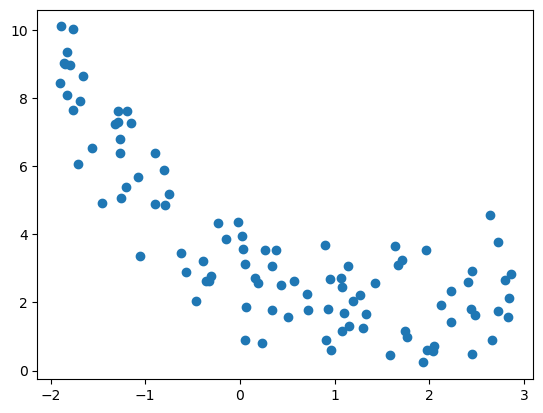

In [51]:
np.random.seed(555)
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [57]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [64]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

In [65]:
pd.DataFrame(data=[loss,bias,variance]).T

,0,1,2
0,298.097882,12.018574,286.079309
1,40.403301,3.323484,37.079818
2,35.557382,2.997278,32.560104
3,32.270084,2.764948,29.505136
4,29.939883,2.585747,27.354136
...,...,...,...
95,34.734520,1.340684,33.393836
96,34.810978,1.341258,33.469720
97,34.886038,1.341840,33.544198
98,34.959722,1.342429,33.617293


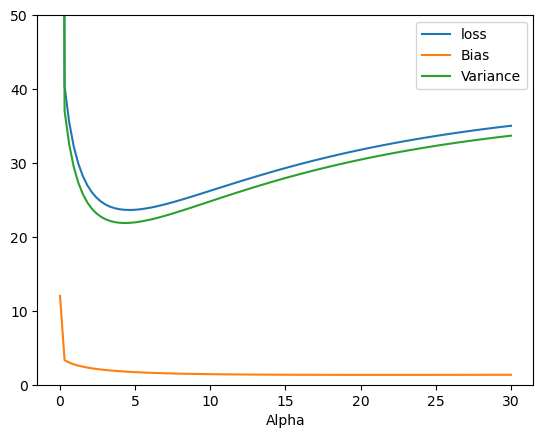

In [72]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,50)
plt.xlabel('Alpha')
plt.legend()
plt.show()

## 4. Effect of Regularization on Loss Function

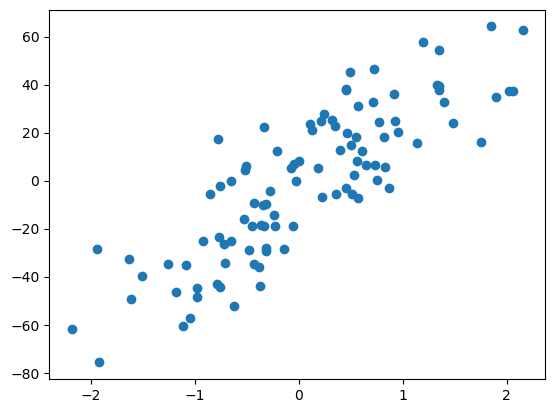

In [ ]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

In [74]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


In [75]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [76]:
def predict(m):
    return m*X - 2.29

humna alag alag hyperparameter value alpha ,lambda ka liya is equation of L,m ko dupara plot kiya tha 

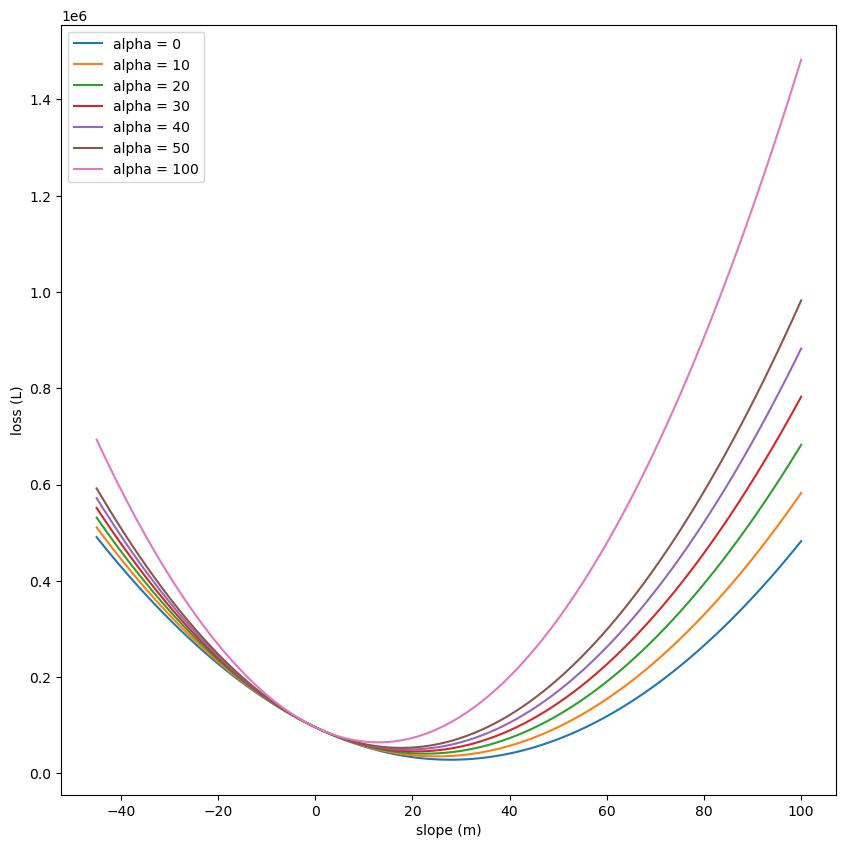

In [84]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(10,10))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('slope (m)')
plt.ylabel('loss (L)')
plt.show()

np.linspace(-45,100,100)

- jab alpha = 0  blue curve tho  slope m: 25 aa raha ha 
- jab alpha = increase kar raha  curve hamra 0 ki taraf shif ho raha ha 

dhira dhira loss func shift ho raha aor origin ki taraf shift ho raha ha 

tho jasa jasa lamda ka value increase ho raha ha tho coeffient wieghts ka value decrease ho raha ha 

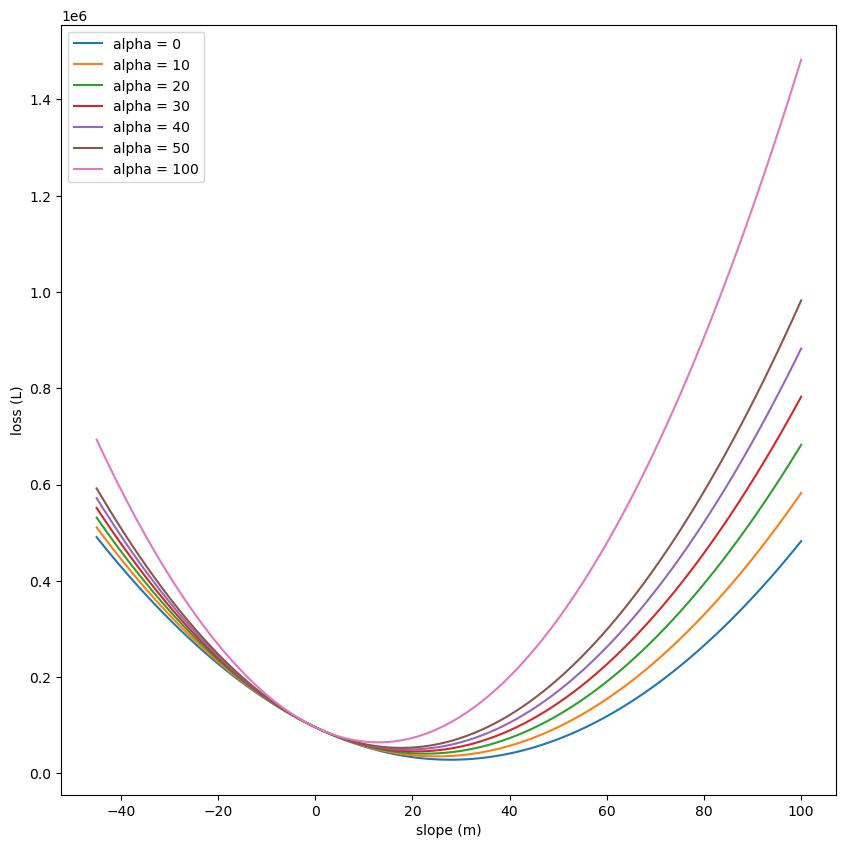

In [93]:
def ridge_regression(alpha_value):
    def cal_loss(m,alpha):
        return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

    def predict(m):
        return m*X - 2.29

    m = np.linspace(-45,100,100)
    plt.figure(figsize=(10,10))
    for j in alpha_value:
        loss = []
        for i in range(m.shape[0]):
            loss_i = cal_loss(m[i],j)
            loss.append(loss_i)
        plt.plot(m,loss,label='alpha = {}'.format(j))
    plt.legend()
    plt.xlabel('slope (m)')
    plt.ylabel('loss (L)')
    plt.show()
    
ridge_regression(alpha_value=[0,10,20,30,40,50,100])